In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.simbad import Simbad
import warnings
warnings.filterwarnings('ignore')

print("Loading groups...")
groups = pd.read_pickle("/home/msp25gd/Downloads/res/meta/groups.pkl")
print(f"Loaded {len(groups)} groups")
print(f"\nGroups columns: {groups.columns.tolist()}")
print(f"\nFirst few rows:")
print(groups.head())

Loading groups...
Loaded 12827 groups

Groups columns: ['New Groups', 'OBJECT', 'Sanitised', 'Reduced', 'DEC', 'EXPTIME', 'MJD-OBS', 'MJD-END', 'WAVELMIN', 'WAVELMAX', 'SPEC_BIN', 'SPEC_RES']

First few rows:
   New Groups          OBJECT       Sanitised        Reduced       DEC  \
0           0    $\alpha$-Cru    $\alpha$ Cru    $\alpha$cru -63.09899   
1           1  $\gamma^2$-Vel  $\gamma^2$ Vel  $\gamma^2$vel -47.33665   
2           2    $\theta$-Car    $\theta$ Car    $\theta$car -64.39407   
3           3     $\zeta$-Pup     $\zeta$ Pup     $\zeta$pup -40.00284   
4           4       0003+1713       0003+1713      0003+1713  17.22642   

     EXPTIME       MJD-OBS       MJD-END    WAVELMIN    WAVELMAX  SPEC_BIN  \
0     5.0078  53747.372964  53747.375327  328.195459  456.300129  0.001358   
1     5.0079  53670.279645  53670.281882  328.192145  456.299040  0.001357   
2    10.0084  53686.311039  53686.313337  328.196918  456.298107  0.001356   
3     5.0081  53670.273791  53670.

In [4]:
import re

# Load the quicksearch candidates (reduced names)
qs_candidates = np.load(
    '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-4sig_2cut_3width.npy',
    allow_pickle=True
)
print(f"Quicksearch candidates: {len(qs_candidates)}")
print(qs_candidates[:10])

# Look up each candidate in groups.pkl using the Reduced column
# OBJECT is the raw FITS header name — same name iplotter passes to Simbad
metadata = pd.read_pickle("/home/msp25gd/Downloads/res/meta/metadata.pkl")

cand_rows = []
for reduced_name in qs_candidates:
    match = groups[groups['Reduced'] == reduced_name]
    if len(match) > 0:
        cand_rows.append(match.iloc[0])
    else:
        # fall back to metadata if the group lookup misses
        meta_match = metadata[metadata['Reduced'] == reduced_name]
        if len(meta_match) > 0:
            row = meta_match.iloc[0].copy()
            cand_rows.append(row)

candidates_df = pd.DataFrame(cand_rows).reset_index(drop=True)
print(f"\nResolved {len(candidates_df)} / {len(qs_candidates)} candidates")
print(f"Columns: {candidates_df.columns.tolist()}")
print(candidates_df[['OBJECT', 'Sanitised', 'Reduced']].head(10))

Quicksearch candidates: 224
['hd323771' 'vssleo' 'walker67' 'hd124314' 'bpsbs169810016' 'sniaa'
 'rylup' 'hd210121' 'hs1606+0153' 'eicha']

Resolved 224 / 224 candidates
Columns: ['New Groups', 'OBJECT', 'Sanitised', 'Reduced', 'DEC', 'EXPTIME', 'MJD-OBS', 'MJD-END', 'WAVELMIN', 'WAVELMAX', 'SPEC_BIN', 'SPEC_RES']
              OBJECT          Sanitised         Reduced
0          HD-323771          HD 323771        hd323771
1           V SS Leo           V SS Leo          vssleo
2          Walker 67          Walker 67        walker67
3          HD 124314          HD 124314        hd124314
4  BPS BS 16981-0016  BPS BS 16981 0016  bpsbs169810016
5            SN Ia A            SN Ia A           sniaa
6             RY-Lup             RY Lup           rylup
7           HD210121           HD210121        hd210121
8        hs1606+0153        hs1606+0153     hs1606+0153
9              EICha              EICha           eicha


In [5]:
# Query Simbad for spectral types using the OBJECT name
# (same approach as iplotter's get_otypes — this name is what Simbad knows)
from astroquery.simbad import Simbad

simbad = Simbad()
simbad.add_votable_fields('sp_type')
simbad.TIMEOUT = 120

print(f"Querying Simbad for {len(candidates_df)} candidates...\n")

sp_types = []
for idx, row in candidates_df.iterrows():
    object_name = row['OBJECT']
    try:
        result = simbad.query_object(object_name)
        if result is not None and len(result) > 0 and 'sp_type' in result.colnames:
            sp_type = str(result['sp_type'][0]).strip()
            sp_types.append(sp_type if sp_type else None)
        else:
            sp_types.append(None)
    except Exception:
        sp_types.append(None)
    print(f"  {idx+1:>3}/{len(candidates_df)}  {object_name:<30}  {sp_types[-1]}")

candidates_df['sp_type'] = sp_types

found = sum(1 for x in sp_types if x)
print(f"\nSpectral types found: {found} / {len(candidates_df)}")

Querying Simbad for 224 candidates...

    1/224  HD-323771                       None
    2/224  V SS Leo                        None
    3/224  Walker 67                       B1V
    4/224  HD 124314                       O6V(n)((f))
    5/224  BPS BS 16981-0016               sdB
    6/224  SN Ia A                         None
    7/224  RY-Lup                          None
    8/224  HD210121                        B7II
    9/224  hs1606+0153                     DA3+dM
   10/224  EICha                           None
   11/224  HD 78344                        O9.5/B0(Ib)
   12/224  HR                              None
   13/224  51-Oph                          None
   14/224  LMC-SC6-57364                   None
   15/224  HR5027                          B0.5Ia
   16/224  bet Pic                         A6V
   17/224  HD-51876                        None
   18/224  2A-1822-371                     None
   19/224  HR6788                          B2II/III
   20/224  HD150136           

In [ ]:
import matplotlib.pyplot as plt

# Extract spectral class (first letter) from full spectral type string
CLASS_ORDER = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'W', 'C', 'S', 'Other', 'Unknown']
CLASS_COLORS = {
    'O': '#3355FF', 'B': '#6699FF', 'A': '#AADDFF',
    'F': '#CCFFEE', 'G': '#FFFF44', 'K': '#FF9900',
    'M': '#FF3333', 'W': '#FF99FF', 'C': '#8B5A2B',
    'S': '#FF6699', 'Other': '#BBBBBB', 'Unknown': '#888888'
}

def to_class(sp_type):
    if not sp_type or str(sp_type).strip() in ('', 'None', 'nan', '--'):
        return 'Unknown'
    letter = sp_type[0].upper()
    return letter if letter in list('OBAFGKMWCS') else 'Other'

candidates_df['sp_class'] = candidates_df['sp_type'].apply(to_class)

counts = candidates_df['sp_class'].value_counts()
# Preserve canonical order, dropping absent classes
present = [c for c in CLASS_ORDER if c in counts]
values  = [counts[c] for c in present]
colors  = [CLASS_COLORS[c] for c in present]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(present, values, color=colors, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Spectral Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Stars', fontsize=12, fontweight='bold')
ax.set_title(
    f'Spectral Type Distribution of QuickSearch Candidates\n'
    f'({len(candidates_df)} candidates from {len(qs_candidates)} total)',
    fontsize=13, fontweight='bold', pad=15
)
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('/home/msp25gd/ResearchProjectMSc/stats/spectral_type_quicksearch.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Summary table
known_total = sum(v for c, v in zip(present, values) if c not in ('Unknown', 'Other'))
print(f"\n{'Class':<8} {'Count':<8} {'%'}")
print('-' * 28)
for cls, val in zip(present, values):
    pct = f'{100*val/known_total:.1f}%' if cls not in ('Unknown', 'Other') else 'N/A'
    print(f"{cls:<8} {val:<8} {pct}")

Raw sample summary
------------------
Metadata source: /home/msp25gd/Downloads/res/meta/full_metadata.pkl
Total spectra in sample: 32308
Total groups: 12827

Percentage of groups with less than 3 spectra: 77.49%
Percentage of groups with less than 10 spectra: 96.36%
Groups with >= 3 spectra: 2887 (22.51%)


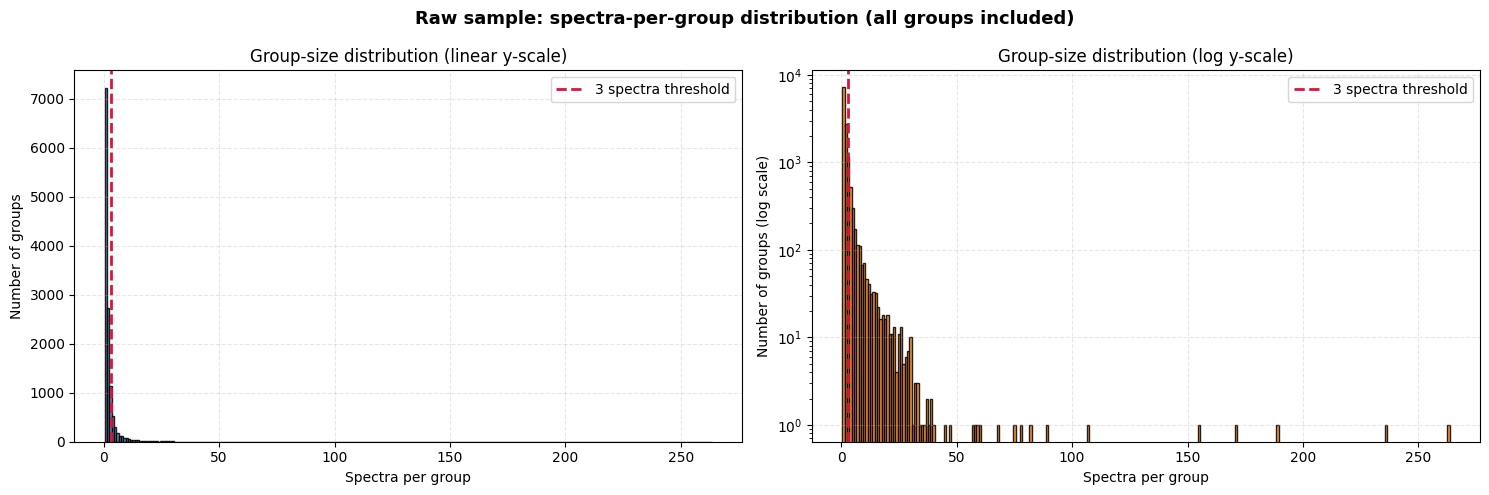

,group_name,spectra_per_group
0,$\alpha$cru,1
1,$\gamma^2$vel,1
2,$\theta$car,1
3,$\zeta$pup,1
4,0003+1713,2


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prefer full metadata for raw-sample assessment; fall back to metadata.pkl if needed.
candidate_paths = [
    '/home/msp25gd/Downloads/res/meta/full_metadata.pkl',
    '/home/msp25gd/Downloads/res/meta/metadata.pkl',
]

metadata_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if metadata_path is None:
    raise FileNotFoundError('Could not find full_metadata.pkl or metadata.pkl in /home/msp25gd/Downloads/res/meta/')

meta_df = pd.read_pickle(metadata_path).copy()

# Resolve grouping column.
group_col = None
for c in ['Reduced', 'reduced', 'New Groups']:
    if c in meta_df.columns:
        group_col = c
        break
if group_col is None:
    raise KeyError('Could not find a grouping column (Reduced/reduced/New Groups).')

# Count spectra per group across the full sample (includes groups with <3 spectra).
group_sizes = meta_df.groupby(group_col, dropna=False).size().rename('spectra_per_group')

total_groups = int(group_sizes.shape[0])
total_spectra = int(meta_df.shape[0])
groups_lt3 = int((group_sizes < 3).sum())
groups_lt10 = int((group_sizes < 10).sum())
groups_ge3 = int((group_sizes >= 3).sum())

pct_lt3 = 100 * groups_lt3 / total_groups
pct_lt10 = 100 * groups_lt10 / total_groups

summary_text = (
    f'Raw sample summary\n'
    f'------------------\n'
    f'Metadata source: {metadata_path}\n'
    f'Total spectra in sample: {total_spectra}\n'
    f'Total groups: {total_groups}\n\n'
    f'Percentage of groups with less than 3 spectra: {pct_lt3:.2f}%\n'
    f'Percentage of groups with less than 10 spectra: {pct_lt10:.2f}%'
 )
print(summary_text)
print(f'Groups with >= 3 spectra: {groups_ge3} ({100*groups_ge3/total_groups:.2f}%)')

# Histogram binning at integer group sizes.
max_size = int(group_sizes.max())
bins = np.arange(0.5, max_size + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear scale view
axes[0].hist(group_sizes.values, bins=bins, color='#4C78A8', edgecolor='black', alpha=0.85)
axes[0].axvline(3, color='crimson', linestyle='--', linewidth=2, label='3 spectra threshold')
axes[0].set_xlabel('Spectra per group')
axes[0].set_ylabel('Number of groups')
axes[0].set_title('Group-size distribution (linear y-scale)')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# Log-scale view for long tail
axes[1].hist(group_sizes.values, bins=bins, color='#F58518', edgecolor='black', alpha=0.85, log=True)
axes[1].axvline(3, color='crimson', linestyle='--', linewidth=2, label='3 spectra threshold')
axes[1].set_xlabel('Spectra per group')
axes[1].set_ylabel('Number of groups (log scale)')
axes[1].set_title('Group-size distribution (log y-scale)')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

fig.suptitle('Raw sample: spectra-per-group distribution (all groups included)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Optional table for downstream use
group_size_table = group_sizes.reset_index().rename(columns={group_col: 'group_name'})
group_size_table.head()

In [47]:
import json
import os
import numpy as np
import pandas as pd
from astropy.time import Time
from IPython import get_ipython
from IPython.display import display

# Keep names defined for static analysis; runtime values are loaded on demand.
ASSET = globals().get('ASSET')
to_reduce = globals().get('to_reduce')


def _load_search_runtime(search_dir='/home/msp25gd/ResearchProjectMSc/HR/search'):
    required = ['ASSET', 'to_reduce']
    missing = [name for name in required if name not in globals()]
    if len(missing) == 0:
        return

    ip = get_ipython()
    if ip is None:
        raise RuntimeError('This helper must run inside a Jupyter notebook kernel.')

    original_cwd = os.getcwd()
    try:
        os.chdir(search_dir)
        for nb_name in ['asset.ipynb', 'reduce_name.ipynb']:
            nb_path = os.path.join(search_dir, nb_name)
            if not os.path.exists(nb_path):
                raise FileNotFoundError(f'Missing required notebook: {nb_path}')
            ip.run_line_magic('run', nb_path)
    finally:
        os.chdir(original_cwd)


def _row_to_datetime(row):
    if 'MJD-OBS' in row.index and pd.notna(row['MJD-OBS']):
        try:
            mjd_value = float(row['MJD-OBS'])
            return pd.Timestamp(Time(mjd_value, format='mjd', scale='utc').to_datetime())
        except Exception:
            pass

    for col in ['Date', 'DATE-OBS', 'DATE_OBS', 'Datetime', 'DATE']:
        if col in row.index and pd.notna(row[col]):
            dt = pd.to_datetime(row[col], errors='coerce', utc=True)
            if pd.notna(dt):
                return pd.Timestamp(dt)

    return pd.NaT


def _row_duration_seconds(row):
    if 'MJD-OBS' in row.index and 'MJD-END' in row.index:
        if pd.notna(row['MJD-OBS']) and pd.notna(row['MJD-END']):
            try:
                duration_seconds = (float(row['MJD-END']) - float(row['MJD-OBS'])) * 86400.0
                if np.isfinite(duration_seconds) and duration_seconds > 0:
                    return float(duration_seconds)
            except Exception:
                pass

    if 'EXPTIME' in row.index and pd.notna(row['EXPTIME']):
        try:
            exptime = float(row['EXPTIME'])
            if np.isfinite(exptime) and exptime > 0:
                return float(exptime)
        except Exception:
            pass

    return np.nan


def _format_duration(duration_seconds):
    if pd.isna(duration_seconds):
        return 'Unknown'

    total_seconds = int(round(float(duration_seconds)))
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    if hours > 0:
        return f'{hours}h {minutes}m {seconds}s'
    if minutes > 0:
        return f'{minutes}m {seconds}s'
    return f'{seconds}s'


def describe_star_detections(
    star_number,
    line='K',
    dataset_root='/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/',
    param_path='/home/msp25gd/ResearchProjectMSc/HR/search/param.json',
    search_dir='/home/msp25gd/ResearchProjectMSc/HR/search',
    date_format='%d/%m/%Y %H:%M:%S',
    show=True,
    include_raw_duration=True,
    raw_duration_round=2,
):
    """Return a readable detection summary and a detected-spectra table for one star."""
    _load_search_runtime(search_dir=search_dir)

    asset_cls = globals().get('ASSET')
    reduce_fn = globals().get('to_reduce')
    if asset_cls is None or reduce_fn is None:
        raise RuntimeError('ASSET/to_reduce helpers are unavailable. Ensure asset.ipynb and reduce_name.ipynb can be loaded.')

    if not os.path.exists(param_path):
        raise FileNotFoundError(f'param.json not found: {param_path}')
    if not os.path.isdir(dataset_root):
        raise FileNotFoundError(f'dataset_root not found: {dataset_root}')

    with open(param_path) as file_obj:
        param = json.load(file_obj)
    param['dataset'] = dataset_root if dataset_root.endswith('/') else dataset_root + '/'

    reduced_name = reduce_fn(str(star_number))
    star_path = os.path.join(param['dataset'], reduced_name)

    if not os.path.isdir(star_path):
        raise FileNotFoundError(
            f"Star folder not found in dataset: {star_path}. Check the star identifier '{star_number}'."
        )

    search = asset_cls(parameters=param, line=line)
    search.ccf = False
    spec_param = search.spec_analysis(star_path + '/')

    if spec_param is None:
        raise ValueError(f'Not enough spectra to analyse detections for {reduced_name}.')

    new_spectra, med, med_err = spec_param

    if not hasattr(search, 'df') or search.df is None:
        raise RuntimeError('ASSET did not expose the metadata table (search.df).')

    spectra_table = search.df.copy().reset_index(drop=True)
    if len(spectra_table) != len(new_spectra):
        raise RuntimeError(
            f'Row mismatch: metadata rows={len(spectra_table)} vs spectra={len(new_spectra)}'
        )

    detection_flags = []
    dip_significance = []
    heliocentric_velocity = []

    for index, spectrum in enumerate(new_spectra):
        snr = search.snr(spectrum, med, search.spectra_err[index], med_err)
        scatter = np.std(snr)
        corr_snr = snr.copy()[search.snr_idxrange]
        sigma = corr_snr / scatter
        min_sigma = float(np.nanmin(sigma))
        filtered_rv = search.radial_velocity[search.snr_idxrange]
        rv_at_minimum = float(filtered_rv[np.nanargmin(sigma)])
        width = float(search.get_width(sigma)) if min_sigma < search.threshold else 0.0
        is_detection = (min_sigma < search.threshold) and (width >= search.width_filter)

        detection_flags.append(bool(is_detection))
        dip_significance.append(min_sigma)
        heliocentric_velocity.append(rv_at_minimum)

    spectra_table['ObservationDateTimeUTC'] = spectra_table.apply(_row_to_datetime, axis=1)
    spectra_table['ObservationDurationSeconds'] = spectra_table.apply(_row_duration_seconds, axis=1)
    spectra_table['Detection'] = detection_flags
    spectra_table['DipSignificanceSigma'] = dip_significance
    spectra_table['HeliocentricVelocity_km_s'] = heliocentric_velocity

    detected_only = spectra_table[spectra_table['Detection']].copy().reset_index(drop=True)
    detected_only['Date'] = detected_only['ObservationDateTimeUTC'].apply(
        lambda value: value.strftime(date_format) if pd.notna(value) else 'Unknown'
    )
    detected_only['DetectionDuration'] = detected_only['ObservationDurationSeconds'].apply(_format_duration)
    detected_only['DipSignificanceSigma'] = detected_only['DipSignificanceSigma'].round(2)
    detected_only['HeliocentricVelocity_km_s'] = detected_only['HeliocentricVelocity_km_s'].round(2)

    output_columns = ['Date', 'DetectionDuration', 'DipSignificanceSigma', 'HeliocentricVelocity_km_s']
    if include_raw_duration:
        detected_only['RawDurationSeconds'] = pd.to_numeric(
            detected_only['ObservationDurationSeconds'], errors='coerce'
        ).round(raw_duration_round)
        output_columns.append('RawDurationSeconds')

    output_table = detected_only[output_columns].rename(
        columns={
            'DipSignificanceSigma': 'DipSignificance (sigma)',
            'HeliocentricVelocity_km_s': 'HeliocentricVelocity (km/s)',
            'RawDurationSeconds': 'RawDurationSeconds',
        }
    )

    total_spectra = int(len(spectra_table))
    detected_spectra = int(len(output_table))

    summary_text = (
        f"Star {reduced_name} has {total_spectra} spectra in total, "
        f"and {detected_spectra} of them contain a detection."
    )

    if show:
        print(summary_text)
        if detected_spectra == 0:
            print('No detected spectra were found for this star.')
        else:
            display(output_table)

    return summary_text, output_table

In [38]:
summary_text, detected_spectra_table = describe_star_detections('twhya')

Star twhya has 3 spectra in total, and 2 of them contain a detection.


,Date,DetectionDuration,DipSignificance (sigma),HeliocentricVelocity (km/s)
0,16/04/2000 23:37:46,31m 40s,-4.32,-13.35
1,17/04/2000 23:17:56,31m 40s,-7.08,20.98


All-group distribution summary
------------------------------
Metadata source: /home/msp25gd/Downloads/res/meta/full_metadata.pkl
Total number of groups: 12827
Mean spectra per group: 2.52
Median spectra per group: 1.00
Std spectra per group: 5.62
Percentage of groups with < 3 spectra: 77.49%
Percentage of groups with < 10 spectra: 96.36%
Percentage of groups with < 20 spectra: 98.89%
Saved figure to: /home/msp25gd/ResearchProjectMSc/Images/finalOtherImages/distribution_of_spectra_per_group.png
Saved figure to: /home/msp25gd/ResearchProjectMSc/Images/finalOtherImages/distribution_of_spectra_per_group.pdf


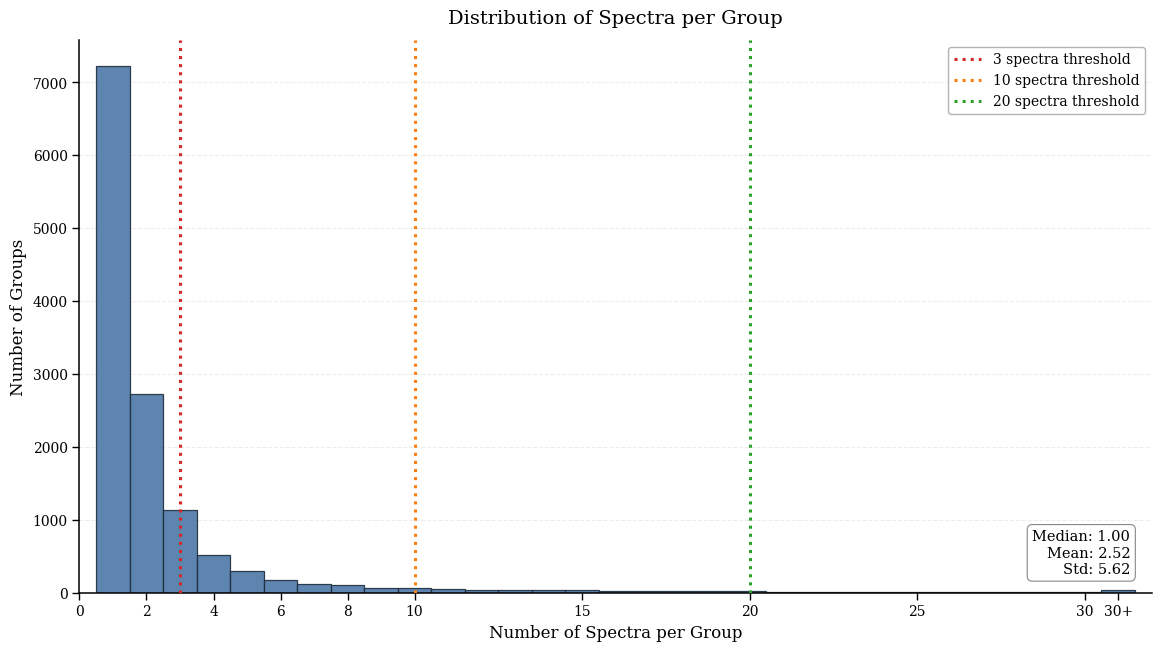

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Publication-like plot styling.
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Load metadata from the full sample (fallback to metadata.pkl if full_metadata.pkl is absent).
candidate_paths = [
    '/home/msp25gd/Downloads/res/meta/full_metadata.pkl',
    '/home/msp25gd/Downloads/res/meta/metadata.pkl',
]

metadata_path = next((path for path in candidate_paths if os.path.exists(path)), None)
if metadata_path is None:
    raise FileNotFoundError('Could not find full_metadata.pkl or metadata.pkl in /home/msp25gd/Downloads/res/meta/')

meta_df = pd.read_pickle(metadata_path).copy()

# Resolve the column that identifies groups.
group_col = None
for col in ['Reduced', 'reduced', 'New Groups']:
    if col in meta_df.columns:
        group_col = col
        break
if group_col is None:
    raise KeyError('Could not find a grouping column (Reduced/reduced/New Groups).')

# Count spectra per group for ALL groups in the sample.
group_sizes = meta_df.groupby(group_col, dropna=False).size().rename('spectra_per_group')

total_groups = int(group_sizes.shape[0])
mean_size = float(group_sizes.mean())
median_size = float(group_sizes.median())
std_size = float(group_sizes.std())

pct_below_3 = 100.0 * float((group_sizes < 3).mean())
pct_below_10 = 100.0 * float((group_sizes < 10).mean())
pct_below_20 = 100.0 * float((group_sizes < 20).mean())

summary_text = (
    'All-group distribution summary\n'
    '------------------------------\n'
    f'Metadata source: {metadata_path}\n'
    f'Total number of groups: {total_groups}\n'
    f'Mean spectra per group: {mean_size:.2f}\n'
    f'Median spectra per group: {median_size:.2f}\n'
    f'Std spectra per group: {std_size:.2f}\n'
    f'Percentage of groups with < 3 spectra: {pct_below_3:.2f}%\n'
    f'Percentage of groups with < 10 spectra: {pct_below_10:.2f}%\n'
    f'Percentage of groups with < 20 spectra: {pct_below_20:.2f}%'
 )
print(summary_text)

# Put all values above 30 into one overflow bin.
plot_values = group_sizes.values.astype(float).copy()
plot_values[plot_values > 30] = 31

# Bins: 1-width bins for 1..30 plus one overflow bin at 30+ (value 31).
bins = np.arange(0.5, 32.5, 1)

fig, ax = plt.subplots(figsize=(11.5, 6.4), constrained_layout=True)
ax.hist(
    plot_values,
    bins=bins,
    color='#4C78A8',
    edgecolor='#1f2d3d',
    linewidth=0.9,
    alpha=0.90,
    zorder=2,
)

ax.axvline(3, color='#D62728', linestyle=':', linewidth=2.2, label='3 spectra threshold', zorder=3)
ax.axvline(10, color='#FF7F0E', linestyle=':', linewidth=2.2, label='10 spectra threshold', zorder=3)
ax.axvline(20, color='#2CA02C', linestyle=':', linewidth=2.2, label='20 spectra threshold', zorder=3)

# Start the chart at (0, 0) and keep plain numeric x labels.
ax.set_xlim(left=0, right=32)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

# Custom ticks with final overflow label.
xticks = [0, 2, 4, 6, 8, 10, 15, 20, 25, 30, 31]
xlabels = ['0', '2', '4', '6', '8', '10', '15', '20', '25', '30', '30+']
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)

# Fine styling suited for publication.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)
ax.tick_params(axis='both', which='major', length=5, width=1.0)

ax.set_xlabel('Number of Spectra per Group')
ax.set_ylabel('Number of Groups')
ax.set_title('Distribution of Spectra per Group', pad=12)
ax.grid(axis='y', alpha=0.22, linestyle='--', linewidth=0.8, zorder=1)
ax.set_axisbelow(True)
ax.legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='#b0b0b0')

# Bottom-right stats box inside the plot.
stats_box = (
    f'Median: {median_size:.2f}\n'
    f'Mean: {mean_size:.2f}\n'
    f'Std: {std_size:.2f}'
)
ax.text(
    0.98, 0.03, stats_box,
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=10.5,
    bbox=dict(
        boxstyle='round,pad=0.35',
        facecolor='white',
        alpha=0.93,
        edgecolor='#7f7f7f',
        linewidth=0.8,
    ),
)

save_dir = '/home/msp25gd/ResearchProjectMSc/Images/finalOtherImages'
os.makedirs(save_dir, exist_ok=True)
save_path_png = os.path.join(save_dir, 'distribution_of_spectra_per_group.png')
save_path_pdf = os.path.join(save_dir, 'distribution_of_spectra_per_group.pdf')
fig.savefig(save_path_png, dpi=400, bbox_inches='tight')
fig.savefig(save_path_pdf, bbox_inches='tight')
print(f'Saved figure to: {save_path_png}')
print(f'Saved figure to: {save_path_pdf}')

plt.show()

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

# HR diagram for all groups with >=3 spectra using Gaia photometry from RA/DEC.
if 'meta_df' not in globals() or 'group_col' not in globals():
    candidate_paths = [
        '/home/msp25gd/Downloads/res/meta/full_metadata.pkl',
        '/home/msp25gd/Downloads/res/meta/metadata.pkl',
    ]
    metadata_path = next((path for path in candidate_paths if os.path.exists(path)), None)
    if metadata_path is None:
        raise FileNotFoundError('Could not find full_metadata.pkl or metadata.pkl in /home/msp25gd/Downloads/res/meta/')
    meta_df = pd.read_pickle(metadata_path).copy()

    group_col = None
    for col in ['Reduced', 'reduced', 'New Groups']:
        if col in meta_df.columns:
            group_col = col
            break
    if group_col is None:
        raise KeyError('Could not find grouping column (Reduced/reduced/New Groups).')

if 'RA' not in meta_df.columns or 'DEC' not in meta_df.columns:
    raise KeyError('This workflow requires RA and DEC columns in metadata.')

group_counts = meta_df.groupby(group_col, dropna=False).size()
eligible_groups = group_counts[group_counts >= 3].index
eligible_df = meta_df[meta_df[group_col].isin(eligible_groups)].copy()

# Use one representative coordinate per group.
representatives = eligible_df[[group_col, 'RA', 'DEC']].dropna().drop_duplicates(subset=[group_col]).copy()

def _to_deg(ra_value, dec_value):
    try:
        # First try decimal degrees.
        ra_deg = float(ra_value)
        dec_deg = float(dec_value)
        return ra_deg, dec_deg
    except Exception:
        # Fallback for sexagesimal strings.
        coord = SkyCoord(str(ra_value), str(dec_value), unit=(u.hourangle, u.deg), frame='icrs')
        return float(coord.ra.deg), float(coord.dec.deg)

representatives[['ra_deg', 'dec_deg']] = representatives.apply(
    lambda row: pd.Series(_to_deg(row['RA'], row['DEC'])), axis=1
)

cache_path = '/home/msp25gd/ResearchProjectMSc/stats/hr_groups_ge3_gaia_cache.csv'
use_cache = os.path.exists(cache_path)

if use_cache:
    gaia_df = pd.read_csv(cache_path)
    print(f'Loaded Gaia cache: {cache_path} ({len(gaia_df)} rows)')
else:
    Gaia.ROW_LIMIT = 1
    rows = []

    for idx, row in representatives.reset_index(drop=True).iterrows():
        ra_deg = float(row['ra_deg'])
        dec_deg = float(row['dec_deg'])
        group_name = row[group_col]

        adql = f"""
            SELECT TOP 1 source_id, bp_rp, phot_g_mean_mag, parallax
            FROM gaiadr3.gaia_source
            WHERE CONTAINS(
                POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
                CIRCLE('ICRS', {ra_deg}, {dec_deg}, {2.0/3600.0})
            ) = 1
            ORDER BY DISTANCE(
                POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
                POINT('ICRS', {ra_deg}, {dec_deg})
            ) ASC
        """

        try:
            job = Gaia.launch_job(adql, dump_to_file=False)
            result = job.get_results()
            if len(result) == 0:
                continue

            rec = result[0]
            rows.append({
                group_col: group_name,
                'source_id': rec['source_id'],
                'bp_rp': rec['bp_rp'],
                'phot_g_mean_mag': rec['phot_g_mean_mag'],
                'parallax': rec['parallax'],
            })
        except Exception:
            continue

        if (idx + 1) % 250 == 0:
            print(f'Queried {idx + 1} / {len(representatives)} groups...')

    gaia_df = pd.DataFrame(rows)
    gaia_df.to_csv(cache_path, index=False)
    print(f'Saved Gaia cache: {cache_path} ({len(gaia_df)} rows)')

if gaia_df.empty:
    raise ValueError('No Gaia matches found for eligible groups.')

gaia_df['bp_rp'] = pd.to_numeric(gaia_df['bp_rp'], errors='coerce')
gaia_df['phot_g_mean_mag'] = pd.to_numeric(gaia_df['phot_g_mean_mag'], errors='coerce')
gaia_df['parallax'] = pd.to_numeric(gaia_df['parallax'], errors='coerce')

hr_df = gaia_df.dropna(subset=['bp_rp', 'phot_g_mean_mag', 'parallax']).copy()
hr_df = hr_df[hr_df['parallax'] > 0].copy()
hr_df['abs_g'] = hr_df['phot_g_mean_mag'] + 5.0 * np.log10(hr_df['parallax']) - 10.0

if hr_df.empty:
    raise ValueError('No valid Gaia points left after quality filtering.')

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    hr_df['bp_rp'],
    hr_df['abs_g'],
    s=12,
    alpha=0.65,
    c=hr_df['bp_rp'],
    cmap='plasma',
    edgecolors='none',
)

ax.invert_yaxis()
ax.set_xlabel('BP - RP (mag)')
ax.set_ylabel('Absolute G Magnitude (mag)')
ax.set_title('HR Diagram for Groups with >= 3 Spectra')
ax.grid(alpha=0.25, linestyle='--')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('BP - RP (mag)')

print(f'Total groups in metadata: {len(group_counts)}')
print(f'Groups with >= 3 spectra: {len(eligible_groups)}')
print(f'Groups with Gaia match: {gaia_df[group_col].nunique()}')
print(f'Plotted points after filtering: {len(hr_df)}')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [52]:
import os
import re
import numpy as np
import pandas as pd

# Find stars (from QuickSearch) that have exactly one detected spectrum with duration in [299, 301] s.
# Also report stars that have any detection at 300.11 s (within tolerance).
quicksearch_candidate_paths = [
    '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-4sig_2cut_3width.npy',
    '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-3.5sig_1.5cut_2width.npy',
    '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width.npy',
    '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy',
    '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2_RES.npy',
    '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/candidate_max_peak_-3.5sig_1.5cut_2width_V2_RES.npy',
]

available_candidate_sets = []
for p in quicksearch_candidate_paths:
    if os.path.exists(p):
        arr = np.load(p, allow_pickle=True)
        available_candidate_sets.append((p, arr))

if len(available_candidate_sets) == 0:
    raise FileNotFoundError(
        'Could not find a QuickSearch candidates file. Checked:\n' + '\n'.join(quicksearch_candidate_paths)
    )

# Prefer the largest set (typically resolution-handled QuickSearch output).
candidate_path, stars_arr = max(available_candidate_sets, key=lambda x: len(x[1]))
stars = [str(s) for s in stars_arr]

print('Available candidate files:')
for p, arr in available_candidate_sets:
    print(f' - {p}: {len(arr)} stars')
print(f'Using candidate file: {candidate_path}')
print(f'Loaded {len(stars)} stars')

def _duration_text_to_seconds(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip()

    h_match = re.search(r'(\d+)h', text)
    m_match = re.search(r'(\d+)m', text)
    s_match = re.search(r'(\d+)s', text)

    hours = int(h_match.group(1)) if h_match else 0
    minutes = int(m_match.group(1)) if m_match else 0
    seconds = int(s_match.group(1)) if s_match else 0

    if h_match or m_match or s_match:
        return float(hours * 3600 + minutes * 60 + seconds)

    raw = pd.to_numeric(text, errors='coerce')
    return float(raw) if pd.notna(raw) else np.nan

target_min = 299.0
target_max = 301.0
target_exact = 300.11
target_tol = 0.02

matched_stars = []
matched_rows = []
failed_stars = []
excluded_multi_hit_stars = []

exact_30011_stars = []
exact_30011_rows = []

for i, star in enumerate(stars, start=1):
    try:
        summary, detected_table = describe_star_detections(
            star,
            show=False,
            include_raw_duration=True,
            raw_duration_round=4,
        )

        if detected_table is None or len(detected_table) == 0:
            continue

        local_table = detected_table.copy()

        # Prefer precise raw seconds if available; otherwise parse formatted text.
        if 'RawDurationSeconds' in local_table.columns:
            local_table['duration_seconds'] = pd.to_numeric(local_table['RawDurationSeconds'], errors='coerce')
        elif 'DetectionDuration' in local_table.columns:
            local_table['duration_seconds'] = local_table['DetectionDuration'].apply(_duration_text_to_seconds)
        else:
            continue

        local_hits = local_table[
            (local_table['duration_seconds'] >= target_min) &
            (local_table['duration_seconds'] <= target_max)
        ].copy()

        if len(local_hits) == 1:
            matched_stars.append(star)
            local_hits.insert(0, 'Star', star)
            matched_rows.append(local_hits)
        elif len(local_hits) > 1:
            excluded_multi_hit_stars.append(star)

        local_exact = local_table[
            np.abs(local_table['duration_seconds'] - target_exact) <= target_tol
        ].copy()
        if len(local_exact) > 0:
            exact_30011_stars.append(star)
            local_exact.insert(0, 'Star', star)
            exact_30011_rows.append(local_exact)

    except Exception as exc:
        failed_stars.append({'Star': star, 'Error': str(exc)})

    if (i % 25 == 0) or (i == len(stars)):
        print(
            f'Processed {i}/{len(stars)} | exact-one matches: {len(matched_stars)} | '
            f'300.11s stars: {len(set(exact_30011_stars))} | '
            f'excluded multi-hit: {len(excluded_multi_hit_stars)} | failed: {len(failed_stars)}'
        )

if len(matched_rows) > 0:
    matches_table = pd.concat(matched_rows, ignore_index=True)
else:
    matches_table = pd.DataFrame(
        columns=['Star', 'Date', 'DetectionDuration', 'DipSignificance (sigma)', 'HeliocentricVelocity (km/s)', 'RawDurationSeconds', 'duration_seconds']
    )

if len(exact_30011_rows) > 0:
    exact_30011_table = pd.concat(exact_30011_rows, ignore_index=True)
else:
    exact_30011_table = pd.DataFrame(
        columns=['Star', 'Date', 'DetectionDuration', 'DipSignificance (sigma)', 'HeliocentricVelocity (km/s)', 'RawDurationSeconds', 'duration_seconds']
    )

unique_matched_stars = sorted(set(matched_stars))
unique_exact_30011_stars = sorted(set(exact_30011_stars))

print('\n=== Result Summary ===')
print(f'Stars checked: {len(stars)}')
print(f'Stars with exactly 1 detection duration in [299, 301] s: {len(unique_matched_stars)}')
print(f'Stars excluded for having >1 detection in [299, 301] s: {len(excluded_multi_hit_stars)}')
print(f'Stars with >=1 detection at {target_exact:.2f} +/- {target_tol:.2f} s: {len(unique_exact_30011_stars)}')
print(f'Failed stars: {len(failed_stars)}')

if len(unique_matched_stars) > 0:
    print('\nMatched stars (exactly one in-window detection):')
    for s in unique_matched_stars:
        print(' -', s)
else:
    print('\nNo stars matched the exact-one [299, 301] s criterion.')

if len(unique_exact_30011_stars) > 0:
    print(f'\nStars with detection near {target_exact:.2f} s:')
    for s in unique_exact_30011_stars:
        print(' -', s)
else:
    print(f'\nNo stars found with detection near {target_exact:.2f} s at tolerance +/-{target_tol:.2f} s.')

print('\nExact-one table:')
display(matches_table)

print(f'\nTable for detections near {target_exact:.2f} s:')
display(exact_30011_table)

if len(failed_stars) > 0:
    failed_table = pd.DataFrame(failed_stars)
    print('\nFirst failures (up to 10):')
    display(failed_table.head(10))

Available candidate files:
 - /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-4sig_2cut_3width.npy: 224 stars
 - /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-3.5sig_1.5cut_2width.npy: 501 stars
 - /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width.npy: 122 stars
 - /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy: 498 stars
 - /home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2_RES.npy: 492 stars
 - /home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/candidate_max_peak_-3.5sig_1.5cut_2width_V2_RES.npy: 492 stars
Using candidate file: /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-3.5sig_1.5cut_2width.npy
Loaded 501 stars
Processed 25/501 | exact-one matches: 1 | 300.11s stars: 0 | excluded multi-hit: 1 | failed: 1
Processed 50/501 | exact-one matches: 3 | 300.11s stars

,Star,Date,DetectionDuration,DipSignificance (sigma),HeliocentricVelocity (km/s),RawDurationSeconds,duration_seconds
0,wd0830535,21/03/2003 01:22:45,5m 0s,-3.85,120.18,300.0011,300.0011
1,pn2119+226,20/03/2003 03:07:41,5m 0s,-3.82,63.71,300.0011,300.0011
2,v595cen,06/04/2002 23:36:22,5m 0s,-3.84,-233.87,299.9910,299.9910
3,hd76131,16/02/2003 04:31:23,5m 0s,-3.67,152.22,300.0011,300.0011
4,hr9006,19/11/2005 00:16:19,5m 0s,-6.01,3.43,300.0016,300.0016
5,hd149447,13/03/2003 09:34:18,5m 0s,-4.22,244.55,300.0011,300.0011
6,wd0320539,31/07/2003 09:43:44,5m 0s,-3.65,-91.18,300.0011,300.0011
7,hd158681,28/07/2024 06:06:02,5m 0s,-4.01,-1.14,299.9998,299.9998
8,wd1148230,09/06/2001 02:00:30,5m 0s,-5.98,-4.96,300.0026,300.0026
9,hd168075,25/08/2009 23:49:03,5m 0s,-4.61,-21.75,300.0017,300.0017



Table for detections near 300.11 s:


,Star,Date,DetectionDuration,DipSignificance (sigma),HeliocentricVelocity (km/s),RawDurationSeconds,duration_seconds



First failures (up to 10):


,Star,Error
0,cd-433604,Star folder not found in dataset: /home/msp25g...
1,tyc8394-1331-1,Star folder not found in dataset: /home/msp25g...
2,tyc7833-1147-1,Star folder not found in dataset: /home/msp25g...
3,cd-2417504,Star folder not found in dataset: /home/msp25g...
4,tyc7196-1656-1,Star folder not found in dataset: /home/msp25g...
5,j03582-3609,Star folder not found in dataset: /home/msp25g...
6,tyc6617-835-1,Star folder not found in dataset: /home/msp25g...
7,tyc9151-303-1,Star folder not found in dataset: /home/msp25g...
8,j0247-25,Star folder not found in dataset: /home/msp25g...
9,tyc421-935-1,Star folder not found in dataset: /home/msp25g...


In [54]:
# Earliest and latest observation across ALL groups (no spectra-count filtering).
import os
import numpy as np
import pandas as pd
from astropy.time import Time

# Prefer full metadata that includes the entire sample.
metadata_candidates = [
    '/home/msp25gd/Downloads/res/meta/full_metadata.pkl',
    '/home/msp25gd/Downloads/res/meta/metadata.pkl',
]
metadata_source = next((p for p in metadata_candidates if os.path.exists(p)), None)
if metadata_source is None:
    raise FileNotFoundError('Could not find full_metadata.pkl or metadata.pkl in /home/msp25gd/Downloads/res/meta/')

all_meta = pd.read_pickle(metadata_source).copy()

# Resolve useful identifier columns.
group_col = None
for c in ['Reduced', 'reduced', 'New Groups']:
    if c in all_meta.columns:
        group_col = c
        break

object_col = None
for c in ['OBJECT', 'Object', 'Sanitised', 'sanitised', group_col]:
    if c is not None and c in all_meta.columns:
        object_col = c
        break


def _row_to_obs_datetime(row):
    # Primary: MJD-OBS
    if 'MJD-OBS' in row.index and pd.notna(row['MJD-OBS']):
        try:
            return pd.Timestamp(Time(float(row['MJD-OBS']), format='mjd', scale='utc').to_datetime())
        except Exception:
            pass

    # Fallback date columns.
    for col in ['Date', 'DATE-OBS', 'DATE_OBS', 'Datetime', 'DATE']:
        if col in row.index and pd.notna(row[col]):
            dt = pd.to_datetime(row[col], errors='coerce', utc=True)
            if pd.notna(dt):
                return pd.Timestamp(dt)

    return pd.NaT


all_meta['ObservationDateTimeUTC'] = all_meta.apply(_row_to_obs_datetime, axis=1)
valid_obs = all_meta[all_meta['ObservationDateTimeUTC'].notna()].copy()

if len(valid_obs) == 0:
    raise ValueError('No valid observation dates found in metadata.')

earliest_idx = valid_obs['ObservationDateTimeUTC'].idxmin()
latest_idx = valid_obs['ObservationDateTimeUTC'].idxmax()

earliest_row = valid_obs.loc[earliest_idx]
latest_row = valid_obs.loc[latest_idx]

earliest_dt = pd.Timestamp(earliest_row['ObservationDateTimeUTC']).strftime('%Y-%m-%d %H:%M:%S UTC')
latest_dt = pd.Timestamp(latest_row['ObservationDateTimeUTC']).strftime('%Y-%m-%d %H:%M:%S UTC')

print('=== Full-Sample Observation Date Range (All Groups) ===')
print(f'Metadata source: {metadata_source}')
print(f'Total rows in metadata: {len(all_meta)}')
print(f'Rows with valid observation datetime: {len(valid_obs)}')
print('')
print(f'Earliest observation: {earliest_dt}')
if group_col is not None:
    print(f'  Group: {earliest_row[group_col]}')
if object_col is not None:
    print(f'  Object: {earliest_row[object_col]}')

print(f'Latest observation:   {latest_dt}')
if group_col is not None:
    print(f'  Group: {latest_row[group_col]}')
if object_col is not None:
    print(f'  Object: {latest_row[object_col]}')


=== Full-Sample Observation Date Range (All Groups) ===
Metadata source: /home/msp25gd/Downloads/res/meta/full_metadata.pkl
Total rows in metadata: 32308
Rows with valid observation datetime: 32308

Earliest observation: 2000-04-05 23:55:18 UTC
  Group: tol1037
  Object: Tol1037
Latest observation:   2025-10-01 09:12:03 UTC
  Group: hd42379
  Object: HD 42379


In [50]:
# Optional follow-up: check stars that failed in degraded dataset against the legacy dataset.
legacy_dataset_root = '/home/msp25gd/Downloads/res/dataset/'
target_exact = 300.11
target_tol = 0.02

failed_star_names = []
if 'failed_stars' in globals() and len(failed_stars) > 0:
    failed_star_names = [str(item['Star']) for item in failed_stars if 'Star' in item]

legacy_hits = []
for i, star in enumerate(failed_star_names, start=1):
    try:
        _, detected_table = describe_star_detections(
            star,
            show=False,
            include_raw_duration=True,
            raw_duration_round=4,
            dataset_root=legacy_dataset_root,
        )

        if detected_table is None or len(detected_table) == 0:
            continue

        t = detected_table.copy()
        t['duration_seconds'] = pd.to_numeric(t.get('RawDurationSeconds', np.nan), errors='coerce')
        hit = t[np.abs(t['duration_seconds'] - target_exact) <= target_tol].copy()
        if len(hit) > 0:
            hit.insert(0, 'Star', star)
            legacy_hits.append(hit)
    except Exception:
        continue

    if (i % 10 == 0) or (i == len(failed_star_names)):
        print(f'Checked {i}/{len(failed_star_names)} failed stars in legacy dataset...')

if len(legacy_hits) > 0:
    legacy_exact_30011_table = pd.concat(legacy_hits, ignore_index=True)
    print(f"\nFound {legacy_exact_30011_table['Star'].nunique()} star(s) near {target_exact:.2f}s in legacy dataset.")
    display(legacy_exact_30011_table)
else:
    print(f'\nNo detections near {target_exact:.2f}s found among failed stars in legacy dataset.')


No detections near 300.11s found among failed stars in legacy dataset.


In [51]:
# Additional check: search 300.11 s detections using the H line.
target_exact = 300.11
target_tol = 0.02
h_line_hits = []

for i, star in enumerate(stars, start=1):
    try:
        _, detected_table_h = describe_star_detections(
            star,
            line='H',
            show=False,
            include_raw_duration=True,
            raw_duration_round=4,
        )
        if detected_table_h is None or len(detected_table_h) == 0:
            continue

        t = detected_table_h.copy()
        t['duration_seconds'] = pd.to_numeric(t.get('RawDurationSeconds', np.nan), errors='coerce')
        hit = t[np.abs(t['duration_seconds'] - target_exact) <= target_tol].copy()
        if len(hit) > 0:
            hit.insert(0, 'Star', star)
            h_line_hits.append(hit)
    except Exception:
        continue

    if (i % 25 == 0) or (i == len(stars)):
        print(f'H-line check {i}/{len(stars)} ...')

if len(h_line_hits) > 0:
    h_line_30011_table = pd.concat(h_line_hits, ignore_index=True)
    print(f"\nFound {h_line_30011_table['Star'].nunique()} star(s) near {target_exact:.2f}s in H line.")
    display(h_line_30011_table)
else:
    print(f'\nNo detections near {target_exact:.2f}s found in H line.')

H-line check 50/224 ...
[q0420388] not enough spectra for the search after cutting noisy spectra!
H-line check 175/224 ...


/tmp/ipykernel_233828/2502250204.py:200: RuntimeWarning: invalid value encountered in divide
  norm_s[i,:] = spec/mean


[hr3476] not enough spectra for the search after cutting noisy spectra!
H-line check 224/224 ...

No detections near 300.11s found in H line.


In [53]:
# Strict degraded-only check (492-star list) for transit duration near 300.11 s.
import numpy as np
import pandas as pd

degraded_candidate_path = '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2_RES.npy'
target_exact = 300.11
target_tol = 0.02

if not os.path.exists(degraded_candidate_path):
    raise FileNotFoundError(f'Missing degraded candidate list: {degraded_candidate_path}')

degraded_stars = [str(s) for s in np.load(degraded_candidate_path, allow_pickle=True)]
print(f'Degraded candidate list size: {len(degraded_stars)}')

degraded_exact_rows = []
degraded_fail = 0

for i, star in enumerate(degraded_stars, start=1):
    try:
        _, det = describe_star_detections(
            star,
            show=False,
            include_raw_duration=True,
            raw_duration_round=4,
            dataset_root='/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/',
        )
        if det is None or len(det) == 0:
            continue

        t = det.copy()
        t['duration_seconds'] = pd.to_numeric(t.get('RawDurationSeconds', np.nan), errors='coerce')
        hit = t[np.abs(t['duration_seconds'] - target_exact) <= target_tol].copy()
        if len(hit) > 0:
            hit.insert(0, 'Star', star)
            degraded_exact_rows.append(hit)
    except Exception:
        degraded_fail += 1

    if (i % 50 == 0) or (i == len(degraded_stars)):
        print(f'Processed {i}/{len(degraded_stars)} | exact hits: {len(degraded_exact_rows)} | failures: {degraded_fail}')

if len(degraded_exact_rows) > 0:
    degraded_exact_30011_table = pd.concat(degraded_exact_rows, ignore_index=True)
    print(f"\nFound {degraded_exact_30011_table['Star'].nunique()} degraded star(s) near {target_exact:.2f}s (+/-{target_tol:.2f}s).")
    display(degraded_exact_30011_table)
else:
    print(f'\nNo degraded stars found with transit duration near {target_exact:.2f}s (+/-{target_tol:.2f}s).')

Degraded candidate list size: 492
Processed 50/492 | exact hits: 0 | failures: 3
Processed 100/492 | exact hits: 0 | failures: 5
Processed 150/492 | exact hits: 0 | failures: 7
Processed 200/492 | exact hits: 0 | failures: 9
Processed 250/492 | exact hits: 0 | failures: 12
Processed 300/492 | exact hits: 0 | failures: 14
Processed 350/492 | exact hits: 0 | failures: 18
Processed 400/492 | exact hits: 0 | failures: 18
Processed 450/492 | exact hits: 0 | failures: 20
Processed 492/492 | exact hits: 0 | failures: 21

No degraded stars found with transit duration near 300.11s (+/-0.02s).


In [55]:
# Pre-degradation check in stats notebook (new bottom cell).
legacy_dataset_root = '/home/msp25gd/Downloads/res/dataset/'
star_to_check = 'hd22049'  # change this star as needed

summary_text_pre, detected_spectra_table_pre = describe_star_detections(
    star_to_check,
    line='K',
    dataset_root=legacy_dataset_root,
    show=False,
    include_raw_duration=True,
    raw_duration_round=4,
)

print('Using dataset:', legacy_dataset_root)
print(summary_text_pre)
print('\nDetected spectra table (pre-degradation):')
display(detected_spectra_table_pre)


Using dataset: /home/msp25gd/Downloads/res/dataset/
Star hd22049 has 4 spectra in total, and 1 of them contain a detection.

Detected spectra table (pre-degradation):


,Date,DetectionDuration,DipSignificance (sigma),HeliocentricVelocity (km/s),RawDurationSeconds
0,12/10/2002 09:24:33,28s,-3.54,136.96,28.0009


In [56]:
# NEW explicit bottom cell: force pre-degradation dataset in stats.
pre_degradation_dataset_root = '/home/msp25gd/Downloads/res/dataset/'
star_to_check_pre = 'hd22049'  # edit target star here

summary_text_pre_v2, detected_spectra_table_pre_v2 = describe_star_detections(
    star_to_check_pre,
    line='K',
    dataset_root=pre_degradation_dataset_root,
    show=False,
    include_raw_duration=True,
    raw_duration_round=4,
)

print('Dataset (forced pre-degradation):', pre_degradation_dataset_root)
print(summary_text_pre_v2)
print('\nDetected spectra table (pre-degradation, explicit cell):')
display(detected_spectra_table_pre_v2)


Dataset (forced pre-degradation): /home/msp25gd/Downloads/res/dataset/
Star hd22049 has 4 spectra in total, and 1 of them contain a detection.

Detected spectra table (pre-degradation, explicit cell):


,Date,DetectionDuration,DipSignificance (sigma),HeliocentricVelocity (km/s),RawDurationSeconds
0,12/10/2002 09:24:33,28s,-3.54,136.96,28.0009


In [ ]:
print("hello world")

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.simbad import Simbad
from astroquery.gaia import Gaia


def _pick_first_existing(paths):
    for path in paths:
        if os.path.exists(path):
            return path
    return None


def _build_quicksearch_v2_known_table():
    # Prefer an in-memory table if it already exists.
    if 'quicksearch_v2_known_sp_table' in globals() and isinstance(quicksearch_v2_known_sp_table, pd.DataFrame):
        table = quicksearch_v2_known_sp_table.copy()
        if {'OBJECT', 'sp_type'}.issubset(table.columns):
            return table

    if 'candidates_df' in globals() and isinstance(candidates_df, pd.DataFrame):
        if {'OBJECT', 'sp_type'}.issubset(candidates_df.columns):
            table = candidates_df[['OBJECT', 'sp_type']].copy()
            table['OBJECT'] = table['OBJECT'].astype(str).str.strip()
            table['sp_type'] = table['sp_type'].astype(str).str.strip()
            table = table[~table['sp_type'].isin(['', 'None', 'nan', '--'])].drop_duplicates('OBJECT')
            if not table.empty:
                return table.reset_index(drop=True)

    candidate_paths = [
        '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2_RES.npy',
        '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy',
        '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width.npy',
    ]
    candidate_path = _pick_first_existing(candidate_paths)
    if candidate_path is None:
        raise FileNotFoundError('Could not find a QuickSearch V2 candidate list file.')

    reduced_names = [str(value) for value in np.load(candidate_path, allow_pickle=True)]

    groups_path = '/home/msp25gd/Downloads/res/meta/groups.pkl'
    metadata_path = '/home/msp25gd/Downloads/res/meta/metadata.pkl'
    groups = pd.read_pickle(groups_path) if os.path.exists(groups_path) else pd.DataFrame()
    metadata = pd.read_pickle(metadata_path) if os.path.exists(metadata_path) else pd.DataFrame()

    object_names = []
    for reduced_name in reduced_names:
        object_name = reduced_name

        if not groups.empty and 'Reduced' in groups.columns and 'OBJECT' in groups.columns:
            match = groups[groups['Reduced'] == reduced_name]
            if len(match) > 0:
                object_name = str(match.iloc[0]['OBJECT'])

        elif not metadata.empty and 'Reduced' in metadata.columns:
            object_col = 'OBJECT' if 'OBJECT' in metadata.columns else None
            if object_col is None and 'Object' in metadata.columns:
                object_col = 'Object'
            if object_col is not None:
                match = metadata[metadata['Reduced'] == reduced_name]
                if len(match) > 0:
                    object_name = str(match.iloc[0][object_col])

        object_names.append(object_name)

    object_names = pd.Series(object_names, dtype='object').dropna().astype(str).str.strip()
    object_names = object_names[object_names != ''].drop_duplicates().tolist()

    if len(object_names) == 0:
        raise ValueError('No object names could be resolved from QuickSearch V2 candidates.')

    simbad = Simbad()
    simbad.add_votable_fields('sp_type', 'ra', 'dec')
    simbad.TIMEOUT = 120

    rows = []
    for index, object_name in enumerate(object_names, start=1):
        try:
            result = simbad.query_object(object_name)
            if result is None or len(result) == 0:
                continue

            sp_type = str(result['sp_type'][0]).strip() if 'sp_type' in result.colnames else ''
            if sp_type in ['', 'None', 'nan', '--']:
                continue

            ra_col = 'ra' if 'ra' in result.colnames else ('ra(d)' if 'ra(d)' in result.colnames else None)
            dec_col = 'dec' if 'dec' in result.colnames else ('dec(d)' if 'dec(d)' in result.colnames else None)
            if ra_col is None or dec_col is None:
                continue

            ra_deg = float(result[ra_col][0])
            dec_deg = float(result[dec_col][0])

            rows.append({
                'OBJECT': object_name,
                'sp_type': sp_type,
                'ra_deg': ra_deg,
                'dec_deg': dec_deg,
            })
        except Exception:
            continue

        if index % 50 == 0 or index == len(object_names):
            print(f'Simbad progress: {index}/{len(object_names)}')

    table = pd.DataFrame(rows)
    if table.empty:
        raise ValueError('No known spectral types were resolved from the QuickSearch V2 list.')

    table = table.dropna(subset=['ra_deg', 'dec_deg']).drop_duplicates(subset=['OBJECT']).reset_index(drop=True)
    if table.empty:
        raise ValueError('Known spectral-type table is empty after coordinate filtering.')

    return table


known_table = _build_quicksearch_v2_known_table()
quicksearch_v2_known_sp_table = known_table.copy()

Gaia.ROW_LIMIT = 1
gaia_rows = []

for index, row in known_table.iterrows():
    ra_deg = float(row['ra_deg'])
    dec_deg = float(row['dec_deg'])

    adql = f"""
        SELECT TOP 1 source_id, bp_rp, phot_g_mean_mag, parallax
        FROM gaiadr3.gaia_source
        WHERE CONTAINS(
            POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
            CIRCLE('ICRS', {ra_deg}, {dec_deg}, {2.0/3600.0})
        ) = 1
        ORDER BY DISTANCE(
            POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
            POINT('ICRS', {ra_deg}, {dec_deg})
        ) ASC
    """

    try:
        job = Gaia.launch_job(adql, dump_to_file=False)
        result = job.get_results()
        if len(result) == 0:
            continue

        rec = result[0]
        gaia_rows.append({
            'OBJECT': row['OBJECT'],
            'sp_type': row['sp_type'],
            'source_id': rec['source_id'],
            'bp_rp': rec['bp_rp'],
            'phot_g_mean_mag': rec['phot_g_mean_mag'],
            'parallax': rec['parallax'],
        })
    except Exception:
        continue

    if (index + 1) % 50 == 0 or (index + 1) == len(known_table):
        print(f'Gaia progress: {index + 1}/{len(known_table)}')

hr_df = pd.DataFrame(gaia_rows)
if hr_df.empty:
    raise ValueError('No Gaia matches found for the known spectral-type table.')

hr_df['bp_rp'] = pd.to_numeric(hr_df['bp_rp'], errors='coerce')
hr_df['phot_g_mean_mag'] = pd.to_numeric(hr_df['phot_g_mean_mag'], errors='coerce')
hr_df['parallax'] = pd.to_numeric(hr_df['parallax'], errors='coerce')
hr_df = hr_df.dropna(subset=['bp_rp', 'phot_g_mean_mag', 'parallax']).copy()
hr_df = hr_df[hr_df['parallax'] > 0].copy()
hr_df['abs_g'] = hr_df['phot_g_mean_mag'] + 5.0 * np.log10(hr_df['parallax']) - 10.0

if hr_df.empty:
    raise ValueError('No valid Gaia points left after filtering.')


def _sp_class(sp_type):
    if pd.isna(sp_type):
        return 'Unknown'
    letter = str(sp_type).strip().upper()[:1]
    return letter if letter in list('OBAFGKM') else 'Other'


hr_df['sp_class'] = hr_df['sp_type'].apply(_sp_class)

class_colors = {
    'O': '#3355FF',
    'B': '#6699FF',
    'A': '#AADDFF',
    'F': '#CCFFEE',
    'G': '#FFFF44',
    'K': '#FF9900',
    'M': '#FF3333',
    'Other': '#999999',
    'Unknown': '#666666',
}

fig, ax = plt.subplots(figsize=(10, 7))

for cls in ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Other', 'Unknown']:
    subset = hr_df[hr_df['sp_class'] == cls]
    if subset.empty:
        continue
    ax.scatter(
        subset['bp_rp'],
        subset['abs_g'],
        s=26,
        alpha=0.75,
        c=class_colors[cls],
        edgecolors='none',
        label=f'{cls} ({len(subset)})',
    )

ax.invert_yaxis()
ax.set_xlabel('BP - RP (mag)')
ax.set_ylabel('Absolute G Magnitude (mag)')
ax.set_title('HR Diagram for QuickSearch V2 Stars with Known Spectral Types')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Spectral class', loc='best', frameon=True)

print(f'Known spectral-type stars (QuickSearch V2): {len(known_table)}')
print(f'Stars with Gaia match: {hr_df["OBJECT"].nunique()}')
print(f'Points plotted: {len(hr_df)}')

plt.tight_layout()
plt.show()

Simbad progress: 50/492
Simbad progress: 200/492
Simbad progress: 300/492
Simbad progress: 400/492
Simbad progress: 450/492
Simbad progress: 492/492


KeyboardInterrupt: 